In [1]:
# ==========================================================
# SOCIAL INTERACTION VIDEO + FIBER PHOTOMETRY SEQUENCES
# ==========================================================

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from scipy.optimize import curve_fit
from scipy.stats import linregress

import re
import warnings


# ==========================================================
# CONFIGURATION
# ==========================================================

# Notebook should be inside write_FP_video
main_dir = Path(".").resolve()

TIMEPOINT = "Preinduction"
FP_ID = "3CT_FP_11_1"

# Behaviour to extract
TARGET_BEHAVIOR = "Social_interaction"

# Movie window
SECONDS_BEFORE = 5.0
SECONDS_AFTER = 2.0

# Your existing pipeline uses 50 Hz
FP_SAMPLING_RATE = 50.0

# Bout cleaning settings from your notebook
MERGE_GAP_S = 2.0
MIN_DURATION_S = 0.0

# Signal displayed in final movie
SIGNAL_COL = "gcamp_dF_F"

# Movie codec
VIDEO_CODEC = "mp4v"

# Output geometry
VIDEO_PANEL_WIDTH = 900
PLOT_PANEL_WIDTH = 900
PANEL_HEIGHT = 650


# ==========================================================
# PATHS
# ==========================================================

tp_dir = main_dir / TIMEPOINT
fp_folder = tp_dir / FP_ID

fp_csv = fp_folder / f"{FP_ID}.csv"

# Output here:
# Preinduction / 3CT_FP_11_1 / video_sequences
output_dir = fp_folder / "video_sequences"
output_dir.mkdir(parents=True, exist_ok=True)


print("Main directory :", main_dir)
print("Timepoint      :", tp_dir)
print("FP folder      :", fp_folder)
print("FP file        :", fp_csv)
print("Output folder  :", output_dir)

Main directory : /Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/Insula/3CT_Combined_manual_annotation/write_FP_video
Timepoint      : /Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/Insula/3CT_Combined_manual_annotation/write_FP_video/Preinduction
FP folder      : /Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/Insula/3CT_Combined_manual_annotation/write_FP_video/Preinduction/3CT_FP_11_1
FP file        : /Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/Insula/3CT_Combined_manual_annotation/write_FP_video/Preinduction/3CT_FP_11_1/3CT_FP_11_1.csv
Output folder  : /Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/Insula/3CT_Combined_manual_annotation/write_FP_video/Preinduction/3CT_FP_11_1/video_sequences


In [2]:
# ==========================================================
# FIND INPUT FILES
# ==========================================================

def find_export_dir(tp_dir):
    """
    Find Export Files regardless of capitalization.
    """
    candidates = [
        p for p in tp_dir.iterdir()
        if p.is_dir() and p.name.lower().replace(" ", "") == "exportfiles"
    ]

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Could not find 'Export Files' inside:\n{tp_dir}"
        )

    return candidates[0]


def read_fp_id_from_export(xlsx_path):
    """
    Read the 'FP file' entry from an EthoVision export file.
    """
    raw = pd.read_excel(xlsx_path, header=None)

    first_col = raw.iloc[:, 0].astype(str).str.strip().str.lower()

    match = raw[first_col == "fp file"]

    if match.empty:
        return None

    idx = match.index[0]

    return str(raw.iloc[idx, 1]).strip()


def find_matching_ethovision_file(export_dir, fp_id):
    """
    Find the EthoVision Raw data file whose metadata says
    FP file == fp_id.
    """
    files = sorted(export_dir.glob("Raw data-*.xlsx"))

    matches = []

    for f in files:
        try:
            this_fp = read_fp_id_from_export(f)

            if this_fp is not None and this_fp.lower() == fp_id.lower():
                matches.append(f)

        except Exception:
            continue

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No EthoVision Raw data file matched FP ID '{fp_id}' "
            f"in {export_dir}"
        )

    if len(matches) > 1:
        print("Multiple EthoVision files matched:")
        for f in matches:
            print(" ", f.name)

        print("\nUsing first match.")

    return matches[0]


# ----------------------------------------------------------
# Timestamp file
# ----------------------------------------------------------

timestamp_candidates = [
    p for p in fp_folder.glob("*.csv")
    if "timestamp" in p.name.lower() or "time" in p.name.lower()
]

timestamp_candidates = [
    p for p in timestamp_candidates
    if p.name.lower() != f"{FP_ID}.csv".lower()
]

if len(timestamp_candidates) == 0:
    raise FileNotFoundError(
        f"No timestamp CSV found in {fp_folder}"
    )

timestamp_csv = timestamp_candidates[0]


# ----------------------------------------------------------
# Video file
# ----------------------------------------------------------

video_candidates = sorted(fp_folder.glob("*.mp4"))

if len(video_candidates) == 0:
    raise FileNotFoundError(
        f"No MP4 video found in {fp_folder}"
    )

if len(video_candidates) > 1:
    print("Multiple MP4 files found:")
    for f in video_candidates:
        print(" ", f.name)
    print("\nUsing first MP4.")

video_file = video_candidates[0]


# ----------------------------------------------------------
# EthoVision file
# ----------------------------------------------------------

export_dir = find_export_dir(tp_dir)

ethovision_file = find_matching_ethovision_file(
    export_dir,
    FP_ID
)


print("\nFILES FOUND")
print("---------------------------------------------")
print("FP          :", fp_csv.name)
print("Timestamp   :", timestamp_csv.name)
print("Video       :", repr(video_file.name))
print("EthoVision  :", ethovision_file.name)


FILES FOUND
---------------------------------------------
FP          : 3CT_FP_11_1.csv
Timestamp   : timestamp1.csv
Video       : 'Trial    17.mp4'
EthoVision  : Raw data-3CT_Preinduction-Trial    17.xlsx


In [3]:
# ==========================================================
# FP AND VIDEO ALIGNMENT
# ==========================================================

def coerce_bool_col(series):
    """
    Convert a digital state column to boolean.

    Handles:
        True / False
        "True" / "False"
        1 / 0
    """

    if series.dtype == bool:
        return series.copy()

    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float) > 0

    low = series.astype(str).str.strip().str.lower()

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "1.0": True,
        "0": False,
        "0.0": False
    }

    return low.map(mapping)


def get_video_window(timestamp_df):
    """
    Determine video start and stop timestamps from timestamp1.csv.

    Expected columns:
        DigitalIOState
        SystemTimestamp

    The video starts at the first DigitalIOState == True
    and stops at the first DigitalIOState == False occurring
    after that start.
    """

    # ------------------------------------------------------
    # Check required columns
    # ------------------------------------------------------
    required_cols = {
        "DigitalIOState",
        "SystemTimestamp"
    }

    missing = required_cols - set(timestamp_df.columns)

    if missing:
        raise ValueError(
            f"Missing required timestamp column(s): {missing}\n"
            f"Available columns: {list(timestamp_df.columns)}"
        )


    # ------------------------------------------------------
    # Convert timestamps to numeric
    # ------------------------------------------------------
    times = pd.to_numeric(
        timestamp_df["SystemTimestamp"],
        errors="coerce"
    )


    if times.isna().all():
        raise ValueError(
            "SystemTimestamp could not be converted to numeric values."
        )


    # ------------------------------------------------------
    # Convert digital state to boolean
    # ------------------------------------------------------
    state = coerce_bool_col(
        timestamp_df["DigitalIOState"]
    )


    if state.isna().all():
        raise ValueError(
            "DigitalIOState could not be interpreted as True/False.\n"
            f"Values found: "
            f"{timestamp_df['DigitalIOState'].dropna().unique()}"
        )


    # ------------------------------------------------------
    # Find video start
    # ------------------------------------------------------
    true_indices = np.where(
        state.to_numpy() == True
    )[0]


    if len(true_indices) == 0:
        raise ValueError(
            "No TRUE DigitalIOState found in timestamp file."
        )


    start_idx = true_indices[0]

    video_start = float(
        times.iloc[start_idx]
    )


    # ------------------------------------------------------
    # Find first FALSE occurring after start
    # ------------------------------------------------------
    false_after_start = np.where(
        (state.to_numpy() == False)
        &
        (np.arange(len(state)) > start_idx)
    )[0]


    if len(false_after_start) == 0:
        raise ValueError(
            "No FALSE DigitalIOState found after video start."
        )


    stop_idx = false_after_start[0]

    video_stop = float(
        times.iloc[stop_idx]
    )


    # ------------------------------------------------------
    # Sanity check
    # ------------------------------------------------------
    if video_stop <= video_start:
        raise ValueError(
            f"Invalid video interval: "
            f"{video_start} to {video_stop}"
        )


    return video_start, video_stop


# ----------------------------------------------------------
# Load timestamp
# ----------------------------------------------------------

timestamp_df = pd.read_csv(timestamp_csv)

print("Timestamp columns:")
print(timestamp_df.columns.tolist())

print("\nDigitalIOState values:")
print(
    timestamp_df["DigitalIOState"]
    .dropna()
    .unique()
)


video_start_system, video_stop_system = get_video_window(
    timestamp_df
)


print(
    f"\nVideo system-time window: "
    f"{video_start_system:.6f} to "
    f"{video_stop_system:.6f} s"
)

print(
    f"Expected video duration: "
    f"{video_stop_system - video_start_system:.3f} s"
)


# ----------------------------------------------------------
# Load FP
# ----------------------------------------------------------

fp_raw = pd.read_csv(
    fp_csv
)


# Keep only the two LED states used in the FP pipeline
fp_raw = fp_raw[
    fp_raw["LedState"].isin([1, 2])
].copy()


# ----------------------------------------------------------
# Check FP timestamp column
# ----------------------------------------------------------

if "SystemTimestamp" not in fp_raw.columns:
    raise ValueError(
        "FP file does not contain SystemTimestamp."
    )


fp_raw["SystemTimestamp"] = pd.to_numeric(
    fp_raw["SystemTimestamp"],
    errors="coerce"
)


if fp_raw["SystemTimestamp"].isna().all():
    raise ValueError(
        "FP SystemTimestamp could not be converted to numeric values."
    )


# ----------------------------------------------------------
# Keep FP samples corresponding to the video interval
# ----------------------------------------------------------

fp_trim = fp_raw[
    (fp_raw["SystemTimestamp"] >= video_start_system)
    &
    (fp_raw["SystemTimestamp"] <= video_stop_system)
].copy()


if fp_trim.empty:
    raise ValueError(
        "No FP samples were found inside the video timestamp window.\n"
        f"Video window: "
        f"{video_start_system:.6f} to "
        f"{video_stop_system:.6f}\n"
        f"FP range: "
        f"{fp_raw['SystemTimestamp'].min():.6f} to "
        f"{fp_raw['SystemTimestamp'].max():.6f}"
    )


# ----------------------------------------------------------
# Convert FP timestamps to VIDEO-RELATIVE time
#
# Video onset = 0 seconds
# ----------------------------------------------------------

fp_trim["Time_video"] = (
    fp_trim["SystemTimestamp"]
    - video_start_system
)


# ----------------------------------------------------------
# Find fluorescence channel
# ----------------------------------------------------------

if "G0" in fp_trim.columns:

    channel = "G0"

else:

    excluded = {
        "LedState",
        "SystemTimestamp",
        "Time_video",
        "Timestamp"
    }

    numeric_candidates = [
        c for c in fp_trim.columns
        if pd.api.types.is_numeric_dtype(fp_trim[c])
        and c not in excluded
    ]

    if len(numeric_candidates) == 0:
        raise ValueError(
            "Could not find a numeric fluorescence channel."
        )

    channel = numeric_candidates[0]


# ----------------------------------------------------------
# Final sanity checks
# ----------------------------------------------------------

print(
    "\nFP fluorescence channel:",
    channel
)

print(
    "FP samples after trimming:",
    len(fp_trim)
)

print(
    "FP system-time range:",
    f"{fp_trim['SystemTimestamp'].min():.6f} to "
    f"{fp_trim['SystemTimestamp'].max():.6f} s"
)

print(
    "FP video-relative range:",
    f"{fp_trim['Time_video'].min():.3f} to "
    f"{fp_trim['Time_video'].max():.3f} s"
)

print(
    "FP video-relative duration:",
    f"{fp_trim['Time_video'].max() - fp_trim['Time_video'].min():.3f} s"
)

Timestamp columns:
['DigitalIOName', 'DigitalIOFlag', 'DigitalIOState', 'SystemTimestamp', 'ComputerTimestamp']

DigitalIOState values:
[ True False]

Video system-time window: 13427.551712 to 13727.446016 s
Expected video duration: 299.894 s

FP fluorescence channel: G0
FP samples after trimming: 14995
FP system-time range: 13427.554528 to 13727.434496 s
FP video-relative range: 0.003 to 299.883 s
FP video-relative duration: 299.880 s


In [4]:
# ==========================================================
# COREGISTER LED 1 AND LED 2
# ==========================================================

iso = fp_trim[
    fp_trim["LedState"] == 1
][["Time_video", channel]].dropna().copy()

gcamp = fp_trim[
    fp_trim["LedState"] == 2
][["Time_video", channel]].dropna().copy()


iso = iso.sort_values("Time_video")
gcamp = gcamp.sort_values("Time_video")


# Common 50 Hz timeline
common_start = max(
    iso["Time_video"].min(),
    gcamp["Time_video"].min()
)

common_stop = min(
    iso["Time_video"].max(),
    gcamp["Time_video"].max()
)


common_time = np.arange(
    common_start,
    common_stop,
    1 / FP_SAMPLING_RATE
)


iso_interp = np.interp(
    common_time,
    iso["Time_video"],
    iso[channel]
)

gcamp_interp = np.interp(
    common_time,
    gcamp["Time_video"],
    gcamp[channel]
)


df = pd.DataFrame({
    "Time_video": common_time,
    "iso415": iso_interp,
    "gcamp470": gcamp_interp
})


print(df.head())
print()
print("Coregistered samples:", len(df))
print(
    "Duration:",
    f"{df['Time_video'].iloc[-1] - df['Time_video'].iloc[0]:.2f} s"
)

   Time_video    iso415  gcamp470
0    0.022816  0.031803  0.034077
1    0.042816  0.031833  0.034034
2    0.062816  0.031818  0.033991
3    0.082816  0.031803  0.033993
4    0.102816  0.031833  0.033995

Coregistered samples: 14992
Duration: 299.82 s


In [5]:
# ==========================================================
# FP PREPROCESSING
# ==========================================================


# ----------------------------------------------------------
# 1. LOW-PASS FILTER
# ----------------------------------------------------------

b_filter, a_filter = butter(
    2,
    10,
    btype="low",
    fs=FP_SAMPLING_RATE
)

df["gcamp_denoised"] = filtfilt(
    b_filter,
    a_filter,
    df["gcamp470"].values
)

df["iso_denoised"] = filtfilt(
    b_filter,
    a_filter,
    df["iso415"].values
)


# ----------------------------------------------------------
# 2. DOUBLE EXPONENTIAL
# ----------------------------------------------------------

def double_exponential(
    t,
    const,
    amp_fast,
    amp_slow,
    tau_slow,
    tau_multiplier
):

    tau_fast = tau_slow * tau_multiplier

    return (
        const
        + amp_slow * np.exp(-t / tau_slow)
        + amp_fast * np.exp(-t / tau_fast)
    )


time_seconds = df["Time_video"].to_numpy()


# ----------------------------------------------------------
# Fit GCaMP bleaching curve
# ----------------------------------------------------------

max_g = np.max(df["gcamp_denoised"])

p0_g = [
    max_g / 2,
    max_g / 4,
    max_g / 4,
    3600,
    0.1
]

bounds_g = (
    [0, 0, 0, 600, 0],
    [max_g, max_g, max_g, 36000, 1]
)


gcamp_params, _ = curve_fit(
    double_exponential,
    time_seconds,
    df["gcamp_denoised"],
    p0=p0_g,
    bounds=bounds_g,
    maxfev=5000
)


df["gcamp_expfit_walton"] = double_exponential(
    time_seconds,
    *gcamp_params
)


# ----------------------------------------------------------
# Fit ISO bleaching curve
# ----------------------------------------------------------

max_iso = np.max(df["iso_denoised"])

p0_iso = [
    max_iso / 2,
    max_iso / 4,
    max_iso / 4,
    3600,
    0.1
]

bounds_iso = (
    [0, 0, 0, 600, 0],
    [max_iso, max_iso, max_iso, 36000, 1]
)


iso_params, _ = curve_fit(
    double_exponential,
    time_seconds,
    df["iso_denoised"],
    p0=p0_iso,
    bounds=bounds_iso,
    maxfev=5000
)


df["iso_expfit_walton"] = double_exponential(
    time_seconds,
    *iso_params
)


# ----------------------------------------------------------
# 3. PHOTOMETRICS BLEACH CORRECTION
# ----------------------------------------------------------

df["iso_expfit_photometrics"] = (
    df["iso_expfit_walton"]
)


X = df["iso_expfit_photometrics"].values
y = df["gcamp_denoised"].values


m, b = np.polyfit(X, y, 1)


df["gcamp_expfit_photometrics"] = (
    m * X + b
)


df["gcamp_corrected_photometrics"] = (
    df["gcamp_denoised"]
    - df["gcamp_expfit_photometrics"]
)


df["iso_corrected_photometrics"] = (
    df["iso_denoised"]
    - df["iso_expfit_photometrics"]
)


# ----------------------------------------------------------
# 4. MOTION CORRECTION
# ----------------------------------------------------------

iso_motion = (
    df["iso_corrected_photometrics"].values
)

gcamp_pre_motion = (
    df["gcamp_corrected_photometrics"].values
)


slope, intercept, r_value, p_value, std_err = linregress(
    iso_motion,
    gcamp_pre_motion
)


gcamp_est_motion = (
    intercept
    + slope * iso_motion
)


df["gcamp_est_motion"] = gcamp_est_motion


df["gcamp_motion_corrected"] = (
    gcamp_pre_motion
    - gcamp_est_motion
)


# ----------------------------------------------------------
# 5. ΔF/F
# ----------------------------------------------------------

df["gcamp_dF_F"] = (
    100
    * df["gcamp_motion_corrected"]
    / df["gcamp_expfit_photometrics"]
)


print("FP preprocessing complete.")

print(
    f"Motion correction R² = "
    f"{r_value**2:.4f}"
)

print()
print(df.columns.tolist())

FP preprocessing complete.
Motion correction R² = 0.0416

['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised', 'gcamp_expfit_walton', 'iso_expfit_walton', 'iso_expfit_photometrics', 'gcamp_expfit_photometrics', 'gcamp_corrected_photometrics', 'iso_corrected_photometrics', 'gcamp_est_motion', 'gcamp_motion_corrected', 'gcamp_dF_F']


/var/folders/3y/jmv30wb16ss901m1yrdysjh80000gq/T/ipykernel_84980/2793307042.py:140: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(X, y, 1)


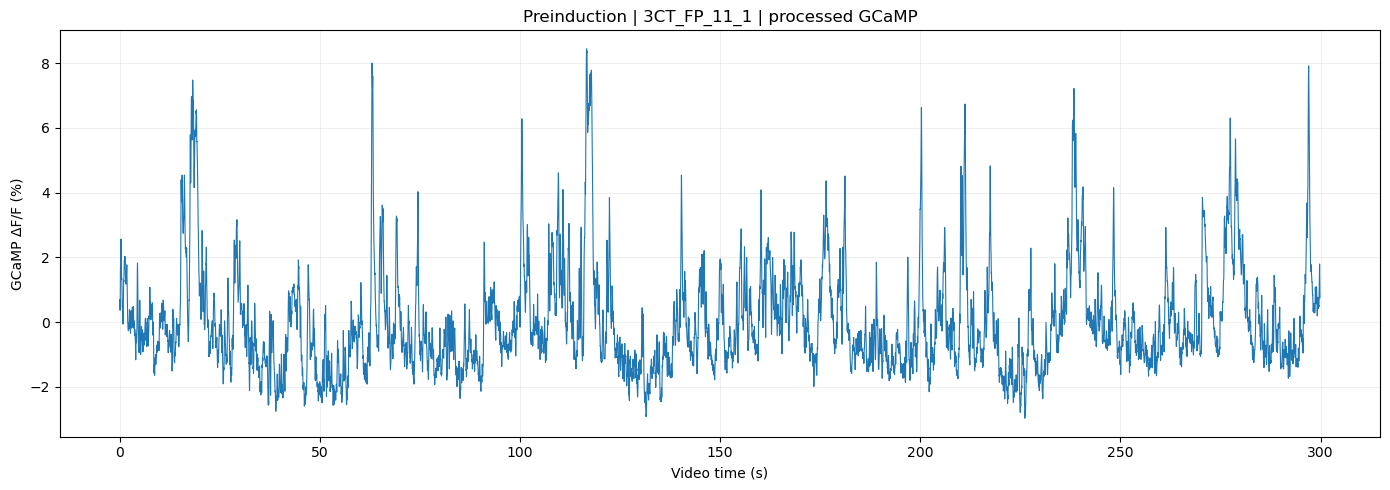

In [6]:
# ==========================================================
# SANITY CHECK FINAL FP TRACE
# ==========================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df["Time_video"],
    df["gcamp_dF_F"],
    linewidth=0.8
)

ax.set_xlabel("Video time (s)")
ax.set_ylabel("GCaMP ΔF/F (%)")
ax.set_title(
    f"{TIMEPOINT} | {FP_ID} | processed GCaMP"
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [7]:
# ==========================================================
# LOAD ETHOVISION BEHAVIOUR DATA
# ==========================================================

BEHAVIOR_KEYWORDS = [
    "Social_interaction",
    "Novel_interaction"
]


def detect_header_row(eth_path):

    preview = pd.read_excel(
        eth_path,
        header=None,
        nrows=50
    )

    first_cell = str(preview.iloc[0, 0])

    if "number of header lines" in first_cell.lower():

        numbers = re.findall(
            r"\d+",
            first_cell
        )

        if numbers:
            return int(numbers[0])


    col0 = preview.iloc[:, 0].astype(str)

    hits = col0[
        col0.str.contains(
            "Trial time",
            case=False,
            na=False
        )
    ]

    if not hits.empty:
        return hits.index[0]


    raise ValueError(
        f"Could not detect header row in "
        f"{eth_path.name}"
    )


def load_ethovision(eth_path):

    header_row = detect_header_row(eth_path)

    eth = pd.read_excel(
        eth_path,
        header=header_row
    ).dropna(
        axis=1,
        how="all"
    )


    # Find trial-time column
    time_col = next(
        (
            c for c in eth.columns
            if "time" in str(c).lower()
        ),
        None
    )


    if time_col is None:
        raise ValueError(
            "Could not identify EthoVision time column."
        )


    eth["Time_s"] = pd.to_numeric(
        eth[time_col],
        errors="coerce"
    )


    # Find interaction columns
    matched_cols = []

    for keyword in BEHAVIOR_KEYWORDS:

        for col in eth.columns:

            if keyword in str(col):
                matched_cols.append(col)
                break


    if not matched_cols:
        raise ValueError(
            "No Social_interaction or "
            "Novel_interaction columns found."
        )


    return (
        eth[["Time_s"] + matched_cols].copy(),
        matched_cols
    )


def ethogram_segments(
    eth,
    behavior_columns
):

    segments = []

    for behavior in behavior_columns:

        mask = eth[behavior] == 1

        if mask.sum() == 0:
            continue


        changes = (
            mask.astype(int)
            .diff()
            .fillna(0)
        )


        starts = eth.loc[
            changes == 1,
            "Time_s"
        ]

        ends = eth.loc[
            changes == -1,
            "Time_s"
        ]


        if mask.iloc[0]:

            starts = pd.concat([
                pd.Series([
                    eth["Time_s"].iloc[0]
                ]),
                starts
            ])


        if mask.iloc[-1]:

            ends = pd.concat([
                ends,
                pd.Series([
                    eth["Time_s"].iloc[-1]
                ])
            ])


        for start, end in zip(starts, ends):

            segments.append({
                "Behavior": behavior,
                "Start_time_s": float(start),
                "End_time_s": float(end),
                "Duration_s": float(end - start)
            })


    return pd.DataFrame(segments)


eth, behavior_columns = load_ethovision(
    ethovision_file
)

timeline_raw = ethogram_segments(
    eth,
    behavior_columns
)


print("Detected behavior columns:")

for c in behavior_columns:
    print(" ", c)


print("\nRaw bouts:")
display(timeline_raw)

Detected behavior columns:
  Social_interaction
  Novel_interaction

Raw bouts:


,Behavior,Start_time_s,End_time_s,Duration_s
0,Social_interaction,15.18,25.48,10.30
1,Social_interaction,28.44,33.62,5.18
2,Social_interaction,44.42,59.58,15.16
3,Social_interaction,73.86,79.66,5.80
4,Social_interaction,100.02,119.44,19.42
5,Social_interaction,216.24,218.54,2.30
6,Social_interaction,227.10,227.70,0.60
7,Social_interaction,233.08,235.30,2.22
8,Social_interaction,249.06,250.72,1.66
9,Social_interaction,268.46,270.86,2.40


In [8]:
# ==========================================================
# CLEAN INTERACTION BOUTS
# ==========================================================

INTERACTION_KEYWORDS = [
    "Social_interaction",
    "Novel_interaction"
]


def clean_interaction_bouts(
    timeline_df,
    interaction_keywords=None,
    min_duration_s=MIN_DURATION_S,
    merge_gap_s=MERGE_GAP_S
):

    if interaction_keywords is None:
        interaction_keywords = INTERACTION_KEYWORDS


    if timeline_df.empty:
        return timeline_df.copy()


    interaction_mask = timeline_df[
        "Behavior"
    ].apply(
        lambda b: any(
            keyword in b
            for keyword in interaction_keywords
        )
    )


    other_rows = timeline_df[
        ~interaction_mask
    ].copy()


    cleaned_parts = []


    for behavior in timeline_df.loc[
        interaction_mask,
        "Behavior"
    ].unique():


        bouts = (
            timeline_df[
                timeline_df["Behavior"] == behavior
            ]
            .sort_values("Start_time_s")
            .reset_index(drop=True)
        )


        if bouts.empty:
            continue


        current_start = float(
            bouts.loc[0, "Start_time_s"]
        )

        current_end = float(
            bouts.loc[0, "End_time_s"]
        )


        merged = []


        for i in range(1, len(bouts)):

            next_start = float(
                bouts.loc[i, "Start_time_s"]
            )

            next_end = float(
                bouts.loc[i, "End_time_s"]
            )


            gap = (
                next_start
                - current_end
            )


            if gap < merge_gap_s:

                current_end = next_end

            else:

                merged.append({
                    "Behavior": behavior,
                    "Start_time_s": current_start,
                    "End_time_s": current_end,
                    "Duration_s":
                        current_end - current_start
                })

                current_start = next_start
                current_end = next_end


        merged.append({
            "Behavior": behavior,
            "Start_time_s": current_start,
            "End_time_s": current_end,
            "Duration_s":
                current_end - current_start
        })


        merged = [
            bout for bout in merged
            if bout["Duration_s"] >= min_duration_s
        ]


        cleaned_parts.extend(merged)


    if cleaned_parts:

        cleaned_df = pd.DataFrame(
            cleaned_parts
        )

        final = pd.concat(
            [other_rows, cleaned_df],
            ignore_index=True
        )

    else:

        final = other_rows.copy()


    return (
        final
        .sort_values("Start_time_s")
        .reset_index(drop=True)
    )


timeline = clean_interaction_bouts(
    timeline_raw
)


social_bouts = timeline[
    timeline["Behavior"].astype(str).str.contains(
        TARGET_BEHAVIOR,
        case=False,
        na=False
    )
].copy()


social_bouts = (
    social_bouts
    .sort_values("Start_time_s")
    .reset_index(drop=True)
)


print(
    f"Found {len(social_bouts)} cleaned "
    f"{TARGET_BEHAVIOR} bouts."
)

display(social_bouts)

Found 12 cleaned Social_interaction bouts.


,Behavior,Start_time_s,End_time_s,Duration_s
0,Social_interaction,15.18,25.48,10.30
1,Social_interaction,28.44,33.62,5.18
2,Social_interaction,44.42,59.58,15.16
3,Social_interaction,73.86,79.66,5.80
4,Social_interaction,100.02,119.44,19.42
5,Social_interaction,216.24,218.54,2.30
6,Social_interaction,227.10,227.70,0.60
7,Social_interaction,233.08,235.30,2.22
8,Social_interaction,249.06,250.72,1.66
9,Social_interaction,268.46,270.86,2.40


In [9]:
# ==========================================================
# VIDEO SANITY CHECK
# ==========================================================

cap = cv2.VideoCapture(
    str(video_file)
)

if not cap.isOpened():
    raise RuntimeError(
        f"Could not open video:\n{video_file}"
    )


video_fps_actual = cap.get(
    cv2.CAP_PROP_FPS
)

video_frame_count = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

video_duration_actual = (
    video_frame_count
    / video_fps_actual
)


video_width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

video_height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)


cap.release()


print("Video file       :", video_file.name)
print("Video FPS        :", video_fps_actual)
print("Frames           :", video_frame_count)
print(
    "Video dimensions :",
    f"{video_width} x {video_height}"
)
print(
    "Video duration   :",
    f"{video_duration_actual:.3f} s"
)

print(
    "FP duration      :",
    f"{df['Time_video'].max():.3f} s"
)

print(
    "Ethogram duration:",
    f"{eth['Time_s'].max():.3f} s"
)

Video file       : Trial    17.mp4
Video FPS        : 49.98304419812356
Frames           : 15034
Video dimensions : 1280 x 1024
Video duration   : 300.782 s
FP duration      : 299.843 s
Ethogram duration: 300.000 s


In [10]:
# ==========================================================
# CREATE STATIC FP PANEL FOR ONE BOUT
# ==========================================================

def create_trace_panel(
    fp_df,
    bout_start,
    bout_end,
    clip_start,
    clip_end,
    signal_col=SIGNAL_COL,
    width=PLOT_PANEL_WIDTH,
    height=PANEL_HEIGHT
):

    # Extract FP data belonging to this movie
    event_fp = fp_df[
        (fp_df["Time_video"] >= clip_start)
        &
        (fp_df["Time_video"] <= clip_end)
    ].copy()


    if event_fp.empty:
        raise ValueError(
            "No FP samples found for this event."
        )


    # Convert x axis to time relative to behaviour onset
    relative_time = (
        event_fp["Time_video"].values
        - bout_start
    )

    signal = event_fp[
        signal_col
    ].values


    bout_duration = bout_end - bout_start


    # Exact pixel size
    dpi = 100

    fig, ax = plt.subplots(
        figsize=(
            width / dpi,
            height / dpi
        ),
        dpi=dpi
    )


    ax.plot(
        relative_time,
        signal,
        linewidth=1.5,
        color="purple"
    )


    # Shade Social_interaction itself
    ax.axvspan(
        0,
        bout_duration,
        color="#377EB8",
        alpha=0.18,
        label="Social interaction"
    )


    # Behaviour onset
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )


    # Behaviour offset
    ax.axvline(
        bout_duration,
        color="black",
        linestyle="--",
        linewidth=1
    )


    ax.axhline(
        0,
        color="gray",
        linewidth=0.7,
        alpha=0.6
    )


    ax.set_xlabel(
        "Time relative to Social_interaction onset (s)"
    )

    ax.set_ylabel(
        "GCaMP ΔF/F (%)"
    )

    ax.set_title(
        "Fiber photometry"
    )

    ax.legend(
        loc="upper right"
    )

    ax.grid(
        alpha=0.15
    )


    # Keep complete event visible throughout movie
    x_min = clip_start - bout_start
    x_max = clip_end - bout_start

    ax.set_xlim(
        x_min,
        x_max
    )


    # Explicit y limits with padding
    finite_signal = signal[
        np.isfinite(signal)
    ]

    y_min = finite_signal.min()
    y_max = finite_signal.max()

    y_range = y_max - y_min

    if y_range == 0:
        y_range = 1


    padding = y_range * 0.10

    ax.set_ylim(
        y_min - padding,
        y_max + padding
    )


    plt.tight_layout()


    # Need final layout before retrieving pixel coordinates
    fig.canvas.draw()


    rgba = np.asarray(
        fig.canvas.buffer_rgba()
    )

    panel_rgb = rgba[:, :, :3].copy()

    # OpenCV uses BGR
    panel_bgr = cv2.cvtColor(
        panel_rgb,
        cv2.COLOR_RGB2BGR
    )


    # Pixel bounds of plotting area.
    # Matplotlib coordinates have y=0 at bottom.
    bbox = ax.get_window_extent()


    axis_geometry = {
        "x0": bbox.x0,
        "x1": bbox.x1,
        "y0": bbox.y0,
        "y1": bbox.y1,
        "x_min": ax.get_xlim()[0],
        "x_max": ax.get_xlim()[1],
        "y_min": ax.get_ylim()[0],
        "y_max": ax.get_ylim()[1],
        "image_height": panel_bgr.shape[0]
    }


    plt.close(fig)


    return (
        panel_bgr,
        axis_geometry
    )

In [11]:
# ==========================================================
# MOVING CURSOR
# ==========================================================

def data_x_to_pixel(x, geom):

    fraction = (
        (x - geom["x_min"])
        /
        (geom["x_max"] - geom["x_min"])
    )

    return int(
        geom["x0"]
        + fraction
        * (geom["x1"] - geom["x0"])
    )


def data_y_to_pixel(y, geom):

    fraction = (
        (y - geom["y_min"])
        /
        (geom["y_max"] - geom["y_min"])
    )

    mpl_y = (
        geom["y0"]
        + fraction
        * (geom["y1"] - geom["y0"])
    )

    # Convert matplotlib bottom-origin to image top-origin
    return int(
        geom["image_height"]
        - mpl_y
    )


def add_trace_cursor(
    panel,
    relative_time,
    current_signal,
    geom
):

    frame = panel.copy()


    x_px = data_x_to_pixel(
        relative_time,
        geom
    )


    y_px = data_y_to_pixel(
        current_signal,
        geom
    )


    top_px = int(
        geom["image_height"]
        - geom["y1"]
    )

    bottom_px = int(
        geom["image_height"]
        - geom["y0"]
    )


    # Moving time cursor
    cv2.line(
        frame,
        (x_px, top_px),
        (x_px, bottom_px),
        (0, 0, 255),
        2
    )


    # Current FP value
    cv2.circle(
        frame,
        (x_px, y_px),
        6,
        (0, 0, 255),
        -1
    )


    return frame

In [12]:
# ==========================================================
# VIDEO RESIZING
# ==========================================================

def resize_with_padding(
    frame,
    target_width,
    target_height
):

    h, w = frame.shape[:2]


    scale = min(
        target_width / w,
        target_height / h
    )


    new_w = int(
        round(w * scale)
    )

    new_h = int(
        round(h * scale)
    )


    resized = cv2.resize(
        frame,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )


    canvas = np.zeros(
        (
            target_height,
            target_width,
            3
        ),
        dtype=np.uint8
    )


    x_offset = (
        target_width - new_w
    ) // 2

    y_offset = (
        target_height - new_h
    ) // 2


    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized


    return canvas

In [13]:
# ==========================================================
# CREATE ONE SOCIAL_INTERACTION MOVIE
# ==========================================================

def create_behavior_movie(
    bout_number,
    bout_start,
    bout_end,
    fp_df,
    video_file,
    output_file
):

    cap = cv2.VideoCapture(
        str(video_file)
    )


    if not cap.isOpened():

        raise RuntimeError(
            f"Could not open video: {video_file}"
        )


    fps = cap.get(
        cv2.CAP_PROP_FPS
    )

    frame_count = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )

    video_duration = (
        frame_count / fps
    )


    # ------------------------------------------------------
    # Requested movie boundaries
    # ------------------------------------------------------

    requested_start = (
        bout_start
        - SECONDS_BEFORE
    )

    requested_end = (
        bout_end
        + SECONDS_AFTER
    )


    # Cannot go outside recording
    clip_start = max(
        0,
        requested_start
    )

    clip_end = min(
        video_duration,
        requested_end
    )


    if clip_start > requested_start:

        print(
            f"[WARN] Bout {bout_number}: "
            f"less than {SECONDS_BEFORE}s available "
            f"before behaviour."
        )


    if clip_end < requested_end:

        print(
            f"[WARN] Bout {bout_number}: "
            f"less than {SECONDS_AFTER}s available "
            f"after behaviour."
        )


    # ------------------------------------------------------
    # FP panel
    # ------------------------------------------------------

    static_panel, geom = create_trace_panel(
        fp_df,
        bout_start,
        bout_end,
        clip_start,
        clip_end
    )


    # ------------------------------------------------------
    # Video writer
    # ------------------------------------------------------

    output_width = (
        VIDEO_PANEL_WIDTH
        + PLOT_PANEL_WIDTH
    )

    output_height = (
        PANEL_HEIGHT
    )


    fourcc = cv2.VideoWriter_fourcc(
        *VIDEO_CODEC
    )


    writer = cv2.VideoWriter(
        str(output_file),
        fourcc,
        fps,
        (
            output_width,
            output_height
        )
    )


    if not writer.isOpened():

        cap.release()

        raise RuntimeError(
            f"Could not create output video:\n"
            f"{output_file}"
        )


    # ------------------------------------------------------
    # Exact frame range
    # ------------------------------------------------------

    start_frame = int(
        np.floor(
            clip_start * fps
        )
    )

    end_frame = int(
        np.ceil(
            clip_end * fps
        )
    )


    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        start_frame
    )


    # ------------------------------------------------------
    # Produce synchronized frames
    # ------------------------------------------------------

    for source_frame_idx in range(
        start_frame,
        end_frame
    ):


        success, video_frame = cap.read()


        if not success:
            break


        # Source video time
        video_time = (
            source_frame_idx / fps
        )


        # Time relative to behaviour onset
        relative_time = (
            video_time
            - bout_start
        )


        # Interpolate FP value at exact video time
        fp_value = np.interp(
            video_time,
            fp_df["Time_video"].values,
            fp_df[SIGNAL_COL].values
        )


        # Moving cursor
        trace_frame = add_trace_cursor(
            static_panel,
            relative_time,
            fp_value,
            geom
        )


        # Resize mouse video
        video_panel = resize_with_padding(
            video_frame,
            VIDEO_PANEL_WIDTH,
            PANEL_HEIGHT
        )


        # --------------------------------------------------
        # Labels on video
        # --------------------------------------------------

        elapsed_from_onset = (
            video_time
            - bout_start
        )


        cv2.putText(
            video_panel,
            f"{TARGET_BEHAVIOR} #{bout_number}",
            (25, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )


        cv2.putText(
            video_panel,
            f"Relative time: {elapsed_from_onset:+.2f} s",
            (25, 80),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )


        # Explicit behaviour status
        if (
            video_time >= bout_start
            and
            video_time <= bout_end
        ):

            status_text = "SOCIAL INTERACTION"

        else:

            status_text = ""


        if status_text:

            cv2.putText(
                video_panel,
                status_text,
                (25, 120),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.75,
                (0, 255, 255),
                2,
                cv2.LINE_AA
            )


        # --------------------------------------------------
        # Side-by-side final frame
        # --------------------------------------------------

        combined = np.hstack([
            video_panel,
            trace_frame
        ])


        writer.write(
            combined
        )


    cap.release()
    writer.release()


    return {
        "bout": bout_number,
        "behavior_start_s": bout_start,
        "behavior_end_s": bout_end,
        "behavior_duration_s":
            bout_end - bout_start,
        "movie_start_s": clip_start,
        "movie_end_s": clip_end,
        "movie_duration_s":
            clip_end - clip_start,
        "output_file": output_file.name
    }

In [14]:
# ==========================================================
# TEST FIRST SOCIAL_INTERACTION ONLY
# ==========================================================

if len(social_bouts) == 0:

    raise ValueError(
        "No Social_interaction bouts were detected."
    )


first_bout = social_bouts.iloc[0]

bout_start = float(
    first_bout["Start_time_s"]
)

bout_end = float(
    first_bout["End_time_s"]
)


test_output = (
    output_dir
    / "TEST_Social_interaction_001.mp4"
)


test_result = create_behavior_movie(
    bout_number=1,
    bout_start=bout_start,
    bout_end=bout_end,
    fp_df=df,
    video_file=video_file,
    output_file=test_output
)


print("\nTEST MOVIE COMPLETE")
print(test_result)
print()
print(test_output)


TEST MOVIE COMPLETE
{'bout': 1, 'behavior_start_s': 15.18, 'behavior_end_s': 25.48, 'behavior_duration_s': 10.3, 'movie_start_s': 10.18, 'movie_end_s': 27.48, 'movie_duration_s': 17.3, 'output_file': 'TEST_Social_interaction_001.mp4'}

/Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/Insula/3CT_Combined_manual_annotation/write_FP_video/Preinduction/3CT_FP_11_1/video_sequences/TEST_Social_interaction_001.mp4


In [15]:
# ==========================================================
# CREATE ALL SOCIAL_INTERACTION MOVIES
# ==========================================================

results = []


for i, row in social_bouts.iterrows():

    bout_number = i + 1

    bout_start = float(
        row["Start_time_s"]
    )

    bout_end = float(
        row["End_time_s"]
    )


    filename = (
        f"{FP_ID}"
        f"__Social_interaction_"
        f"{bout_number:03d}"
        f"__start_{bout_start:.2f}s"
        f"__end_{bout_end:.2f}s"
        f".mp4"
    )


    output_file = (
        output_dir
        / filename
    )


    print(
        f"\nCreating bout "
        f"{bout_number}/{len(social_bouts)}"
    )

    print(
        f"Behaviour: "
        f"{bout_start:.2f} to "
        f"{bout_end:.2f} s"
    )


    try:

        result = create_behavior_movie(
            bout_number=bout_number,
            bout_start=bout_start,
            bout_end=bout_end,
            fp_df=df,
            video_file=video_file,
            output_file=output_file
        )


        results.append(
            result
        )


        print(
            "Saved:",
            output_file.name
        )


    except Exception as e:

        print(
            f"[WARN] Could not create "
            f"bout {bout_number}: {e}"
        )


print(
    f"\nFinished. "
    f"{len(results)} movies created."
)


Creating bout 1/12
Behaviour: 15.18 to 25.48 s
Saved: 3CT_FP_11_1__Social_interaction_001__start_15.18s__end_25.48s.mp4

Creating bout 2/12
Behaviour: 28.44 to 33.62 s
Saved: 3CT_FP_11_1__Social_interaction_002__start_28.44s__end_33.62s.mp4

Creating bout 3/12
Behaviour: 44.42 to 59.58 s
Saved: 3CT_FP_11_1__Social_interaction_003__start_44.42s__end_59.58s.mp4

Creating bout 4/12
Behaviour: 73.86 to 79.66 s
Saved: 3CT_FP_11_1__Social_interaction_004__start_73.86s__end_79.66s.mp4

Creating bout 5/12
Behaviour: 100.02 to 119.44 s
Saved: 3CT_FP_11_1__Social_interaction_005__start_100.02s__end_119.44s.mp4

Creating bout 6/12
Behaviour: 216.24 to 218.54 s
Saved: 3CT_FP_11_1__Social_interaction_006__start_216.24s__end_218.54s.mp4

Creating bout 7/12
Behaviour: 227.10 to 227.70 s
Saved: 3CT_FP_11_1__Social_interaction_007__start_227.10s__end_227.70s.mp4

Creating bout 8/12
Behaviour: 233.08 to 235.30 s
Saved: 3CT_FP_11_1__Social_interaction_008__start_233.08s__end_235.30s.mp4

Creating bout 9

In [16]:
# ==========================================================
# SAVE MOVIE INDEX
# ==========================================================

movie_index = pd.DataFrame(
    results
)


index_file = (
    output_dir
    / "Social_interaction_video_sequences.csv"
)


movie_index.to_csv(
    index_file,
    index=False
)


display(movie_index)

print(
    "\nSaved movie index to:"
)

print(index_file)

,bout,behavior_start_s,behavior_end_s,behavior_duration_s,movie_start_s,movie_end_s,movie_duration_s,output_file
0,1,15.18,25.48,10.30,10.18,27.480,17.300,3CT_FP_11_1__Social_interaction_001__start_15....
1,2,28.44,33.62,5.18,23.44,35.620,12.180,3CT_FP_11_1__Social_interaction_002__start_28....
2,3,44.42,59.58,15.16,39.42,61.580,22.160,3CT_FP_11_1__Social_interaction_003__start_44....
3,4,73.86,79.66,5.80,68.86,81.660,12.800,3CT_FP_11_1__Social_interaction_004__start_73....
4,5,100.02,119.44,19.42,95.02,121.440,26.420,3CT_FP_11_1__Social_interaction_005__start_100...
5,6,216.24,218.54,2.30,211.24,220.540,9.300,3CT_FP_11_1__Social_interaction_006__start_216...
6,7,227.10,227.70,0.60,222.10,229.700,7.600,3CT_FP_11_1__Social_interaction_007__start_227...
7,8,233.08,235.30,2.22,228.08,237.300,9.220,3CT_FP_11_1__Social_interaction_008__start_233...
8,9,249.06,250.72,1.66,244.06,252.720,8.660,3CT_FP_11_1__Social_interaction_009__start_249...
9,10,268.46,270.86,2.40,263.46,272.860,9.400,3CT_FP_11_1__Social_interaction_010__start_268...



Saved movie index to:
/Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/Insula/3CT_Combined_manual_annotation/write_FP_video/Preinduction/3CT_FP_11_1/video_sequences/Social_interaction_video_sequences.csv
